In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_curve, auc

%matplotlib inline

# =========================
# LOAD + LIMPEZA
# =========================

# Carregar dataset
df = pd.read_csv("../data/cardio_train.csv", sep=";")

# Remover ID (não é necessário para o modelo)
if "id" in df.columns:
    df = df.drop(columns=["id"])

# remover outliers
df = df[(df["ap_hi"] > 80) & (df["ap_hi"] < 250)]
df = df[(df["ap_lo"] > 50) & (df["ap_lo"] < 150)]

Predição de Acidente Vascular Cerebral (AVC) com Machine Learning

Problema e Coleta de Dados

O objetivo deste projeto é prever a ocorrência de AVC com base em características clínicas e demográficas dos pacientes.

O problema é de classificação binária:

- 0 → Sem doença cardiovascular  
- 1 → Com doença cardiovascular  

Este tipo de problema é crítico na área da saúde, pois permite identificação precoce de riscos.

Feature Engineering

Criamos novas variáveis para melhorar a capacidade preditiva do modelo.

In [18]:
# =========================
# FEATURE ENGINEERING
# =========================
df["age_years"] = df["age"] / 365

df["bmi"] = df["weight"] / ((df["height"] / 100) ** 2)

df["pulse_pressure"] = df["ap_hi"] - df["ap_lo"]
df["mean_pressure"] = (df["ap_hi"] + df["ap_lo"]) / 2

df["high_pressure"] = (df["ap_hi"] > 140).astype(int)
df["high_cholesterol"] = (df["cholesterol"] > 1).astype(int)
df["high_glucose"] = (df["gluc"] > 1).astype(int)

df["risk_score"] = (
    df["high_pressure"] +
    df["high_cholesterol"] +
    df["high_glucose"] +
    df["smoke"]
)

df["pressure_age"] = df["ap_hi"] * df["age_years"]

As features criadas representam melhor o risco cardiovascular do paciente, simulando indicadores clínicos reais.

Correlação entre variáveis

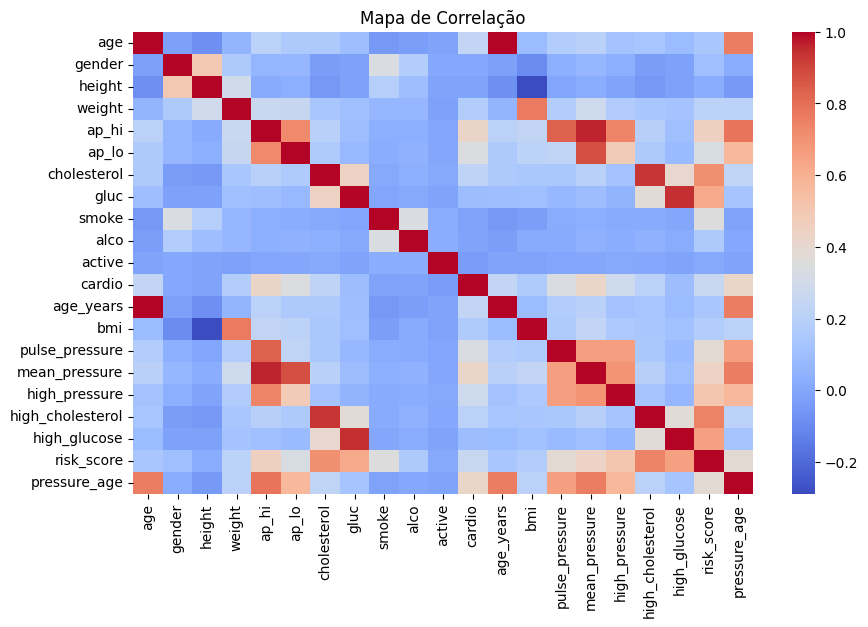

In [19]:
# =========================
# EDA
# =========================

# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Mapa de Correlação")
plt.show()

Variáveis relacionadas à pressão e idade apresentam maior correlação com a doença cardiovascular.

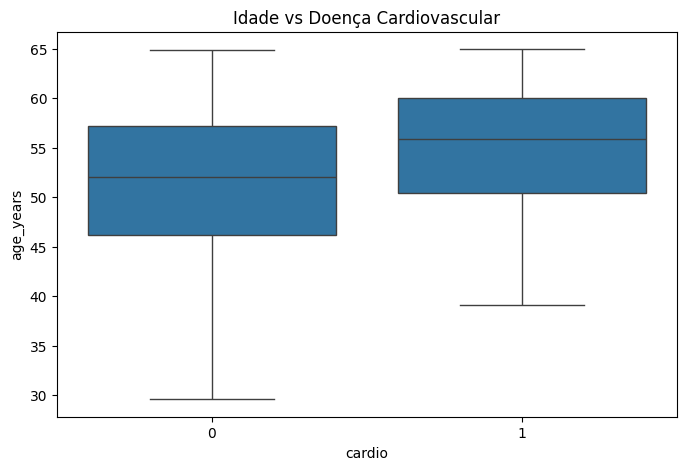

In [20]:
# Boxplots
plt.figure(figsize=(8,5))
sns.boxplot(x="cardio", y="age_years", data=df)
plt.title("Idade vs Doença Cardiovascular")
plt.show()

Pacientes com doença cardiovascular tendem a apresentar maior idade, pressão arterial e BMI.

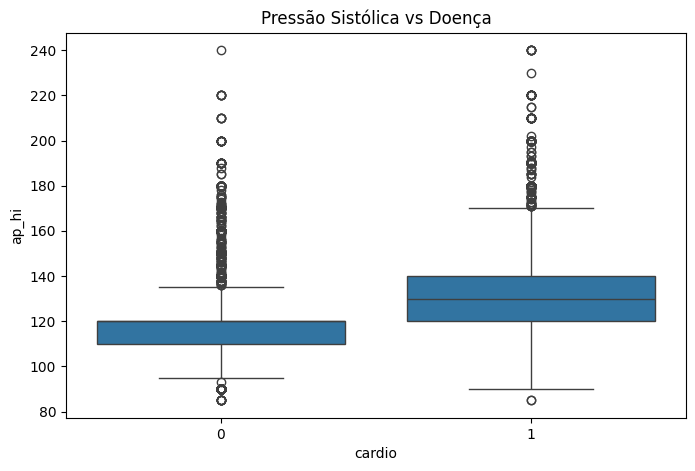

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x="cardio", y="ap_hi", data=df)
plt.title("Pressão Sistólica vs Doença")
plt.show()

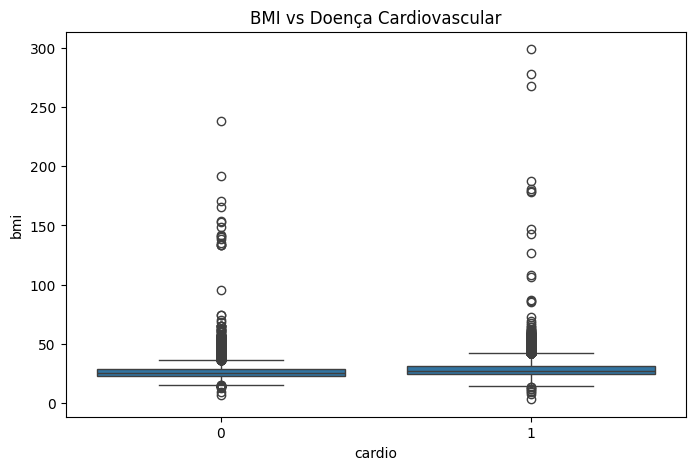

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x="cardio", y="bmi", data=df)
plt.title("BMI vs Doença Cardiovascular")
plt.show()

Variáveis relacionadas à pressão e idade apresentam maior correlação com a doença cardiovascular.

In [23]:
# =========================
# MODELO (VERSÃO SIMPLES PARA ANÁLISE)
# =========================
X = df.drop("cardio", axis=1)
y = df["cardio"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = XGBClassifier(eval_metric="logloss")
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

Treinamento do Modelo

Utilizamos o XGBoost, um modelo baseado em árvores altamente eficiente.

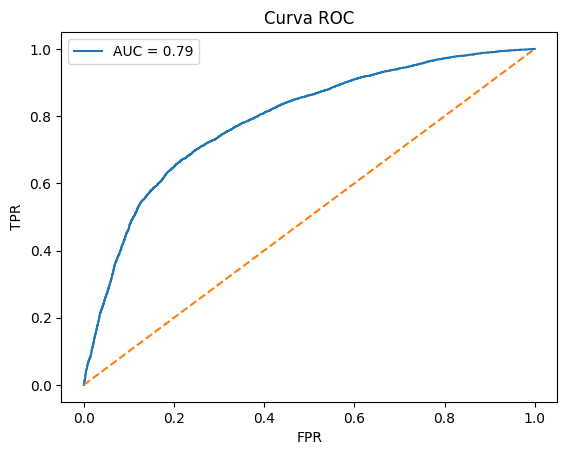

In [24]:
# =========================
# CURVA ROC
# =========================
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curva ROC")
plt.legend()
plt.show()

Curva ROC

Avalia a capacidade do modelo de separar as classes.

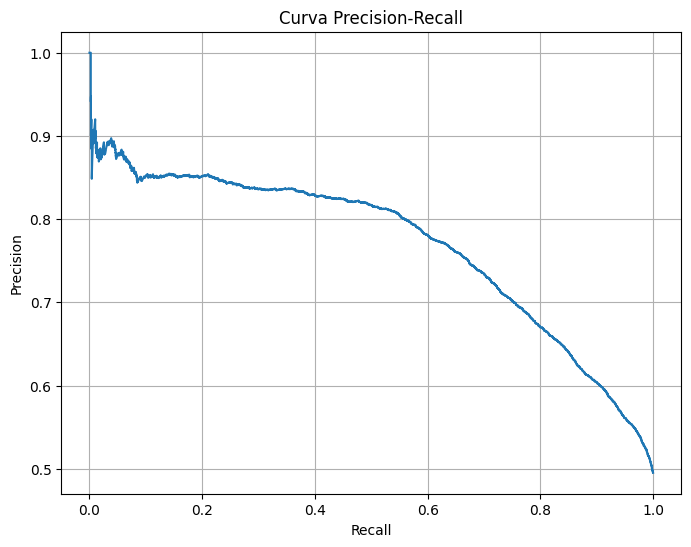

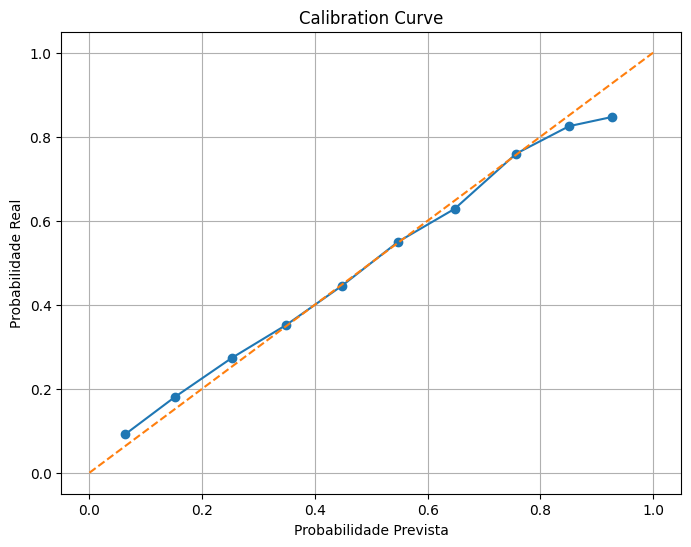

In [25]:
# =========================
# PRECISION-RECALL
# =========================
from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.grid()
plt.show()


# =========================
# CALIBRATION CURVE
# =========================
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure(figsize=(8,6))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Probabilidade Prevista")
plt.ylabel("Probabilidade Real")
plt.title("Calibration Curve")
plt.grid()
plt.show()

Curva Precision-Recall

Mais adequada para datasets desbalanceados.

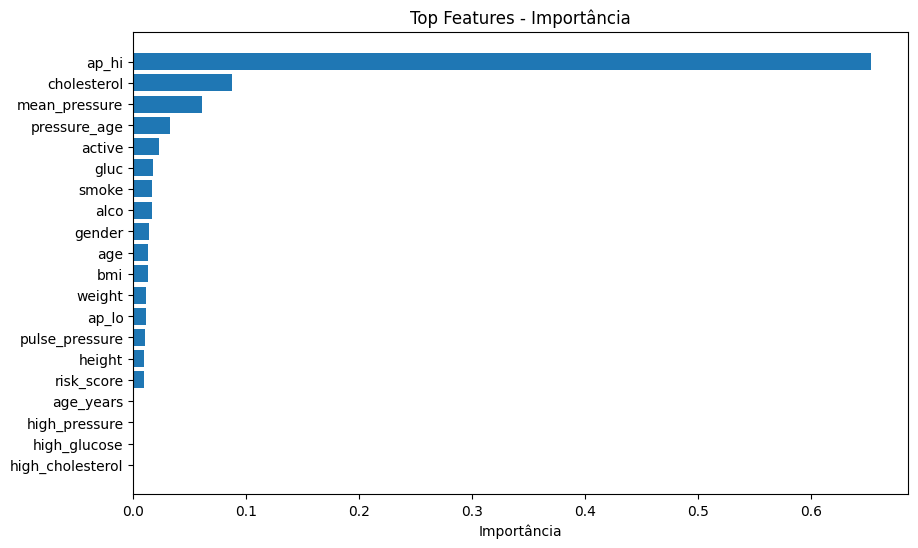

In [26]:
# =========================
# FEATURE IMPORTANCE
# =========================
importance = model.feature_importances_

feat_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": importance
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feat_importance["feature"], feat_importance["importance"])
plt.gca().invert_yaxis()
plt.title("Top Features - Importância")
plt.xlabel("Importância")
plt.show()

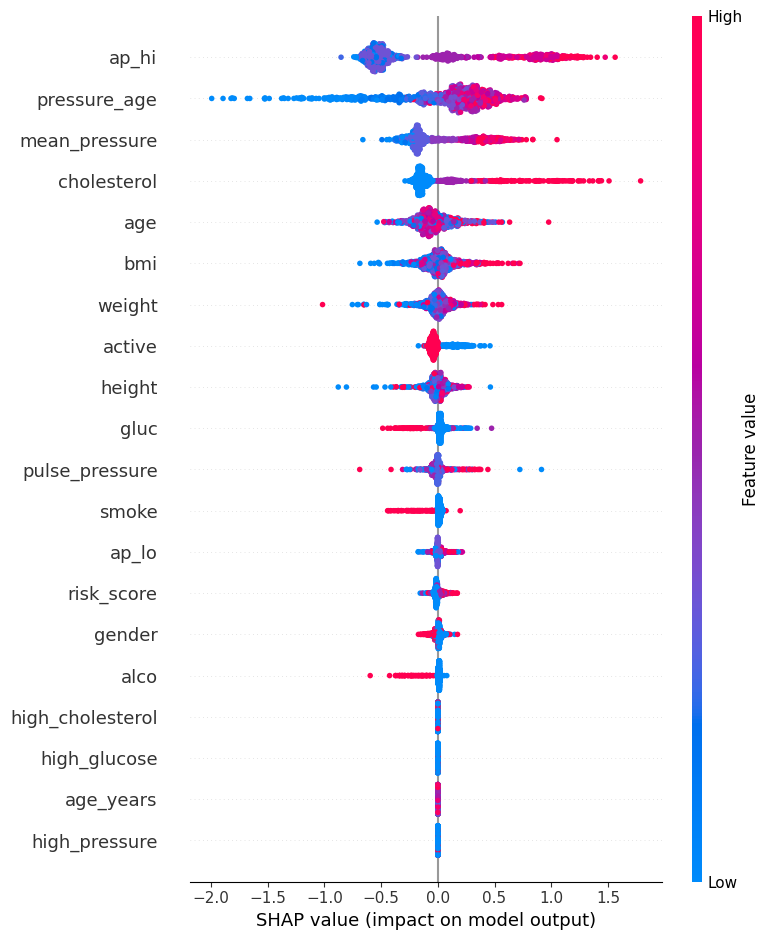

In [27]:
# =========================
# SHAP (INTERPRETAÇÃO)
# =========================
explainer = shap.TreeExplainer(model)

X_test_sample = X_test.sample(1000, random_state=42)
shap_values_sample = explainer.shap_values(X_test_sample)

shap.summary_plot(shap_values_sample, X_test_sample)